# Interference Classification in O-RAN — EfficientNetB0

Transfer-learning classifier that labels a channel **spectrogram** as one of three
classes: **SOI** (signal of interest, no jamming), **SOI+CWI** (continuous-wave
interference) or **SOI+CI** (chirped interference). Backbone: EfficientNetB0
(ImageNet weights) + GlobalAveragePooling2D + Dropout(0.2) + Dense(3, softmax),
trained in two phases (frozen base, then last-30-layers fine-tune).

**Data:** RGB spectrogram PNGs under `directory`, one subfolder per class
(`CI/`, `CWI/`, `SOI/`). The images are generated from a modified **srsRAN** LTE
O-RAN testbed and are *not* bundled with this repo (see the project README).



In [1]:
# Cell 1: Imports + environment setup (runs on Google Colab AND locally in Jupyter)
import os
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Where the dataset lives + where to write the on-disk tf.data cache.
try:
    from google.colab import drive            # --- running on Google Colab ---
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/cleaned'
    CACHE_DIR = '/content/tf_cache'
except ModuleNotFoundError:                    # --- running locally (Jupyter Lab) ---
    DATA_DIR = 'C:/Users/Osman Mamudu/Documents/jamming/data/cleaned'   # has CI/ CWI/ SOI/
    CACHE_DIR = 'C:/Users/Osman Mamudu/Documents/jamming/.tf_cache'     # any writable folder

print("Data dir :", DATA_DIR)
print("Cache dir:", CACHE_DIR)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Data dir : C:/Users/Osman Mamudu/Documents/jamming/data/cleaned
Cache dir: C:/Users/Osman Mamudu/Documents/jamming/.tf_cache
Num GPUs Available: 0


In [2]:
# Cell 2: Dataset directory and (optional) original image properties
directory = DATA_DIR

# Only treat sub-directories as classes (ignores stray files like .DS_Store).
class_names = sorted(
    d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))
)
print("Class names:", class_names)

def get_image_shape(directory, class_name):
    class_dir = os.path.join(directory, class_name)
    image_path = os.path.join(class_dir, os.listdir(class_dir)[0])
    return np.array(Image.open(image_path)).shape

print(f"Original image shape: {get_image_shape(directory, class_names[0])}")

Class names: ['CI', 'CWI', 'SOI']
Original image shape: (256, 256, 3)


In [3]:
# Cell 3: Load dataseclass-balanced 70/20/10 split, then augment + preprocess



IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Cache to LOCAL DISK, not RAM 
shutil.rmtree(CACHE_DIR, ignore_errors=True)   # start clean (avoid stale/partial caches)
os.makedirs(CACHE_DIR, exist_ok=True)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=directory,
    validation_split=0.3,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
)
class_names = train_dataset.class_names          # authoritative label order
print("Class names:", class_names)

rest_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=directory,
    validation_split=0.3,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
)

# Freeze the held-out set order on DISK, then carve a stable, disjoint val/test split.
rest_dataset = rest_dataset.cache(os.path.join(CACHE_DIR, 'rest'))
for _ in rest_dataset:
    pass
rest_batches = tf.data.experimental.cardinality(rest_dataset).numpy()
val_batches = int(round(rest_batches * (2.0 / 3.0)))   # 20% of total = 2/3 of the 30%
val_dataset = rest_dataset.take(val_batches)
test_dataset = rest_dataset.skip(val_batches)

print(f"Train batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Val batches:   {val_batches}")
print(f"Test batches:  {rest_batches - val_batches}")

# EfficientNet expects raw [0,255] inputs; its preprocess_input is a pass-through that
# preserves that contract, so we do NOT rescale to [0,1] here.
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

def preprocess_image(image, label):
    return tf.keras.applications.efficientnet.preprocess_input(image), label

# Train: disk-cache the deterministic preprocessing, then shuffle + augment each epoch.
train_dataset = (train_dataset
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache(os.path.join(CACHE_DIR, 'train'))
                 .shuffle(1000)
                 .map(augment_image, num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))
# val/test stream from the frozen rest disk-cache above; preprocess_input is a no-op, so
# there is no need to cache them again (this also keeps RAM low).
val_dataset = val_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 7912 files belonging to 3 classes.
Using 5539 files for training.
Class names: ['CI', 'CWI', 'SOI']
Found 7912 files belonging to 3 classes.
Using 2373 files for validation.
Train batches: 174
Val batches:   50
Test batches:  25


In [4]:
# Cell 4: Define Model with Dropout
# Load EfficientNetB0 base model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Build model with dropout
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 4,011,391 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [5]:
# Cell 5: Two-Step Training with Early Stopping
# Step 1: Train top layers
base_model.trainable = False
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1 = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

# Step 2: Fine-tune with early stopping
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history2 = model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[early_stopping])


Epoch 1/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 141s 695ms/step - accuracy: 0.9413 - loss: 0.2408 - val_accuracy: 0.9806 - val_loss: 0.1066
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 124s 699ms/step - accuracy: 0.9792 - loss: 0.0938 - val_accuracy: 0.9844 - val_loss: 0.0815
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 122s 690ms/step - accuracy: 0.9845 - loss: 0.0721 - val_accuracy: 0.9862 - val_loss: 0.0736
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 124s 700ms/step - accuracy: 0.9856 - loss: 0.0673 - val_accuracy: 0.9862 - val_loss: 0.0733
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 122s 693ms/step - accuracy: 0.9859 - loss: 0.0627 - val_accuracy: 0.9825 - val_loss: 0.0745
Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 163s 854ms/step - accuracy: 0.9816 - loss: 0.0772 - val_accuracy: 0.9875 - val_loss: 0.0601
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 146s 829ms/step - accuracy: 0.9881 - loss: 0.0503 - val_accuracy: 0.9881 - val_loss: 0.0637
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 146s 829ms/step - accuracy: 0.9883 - loss

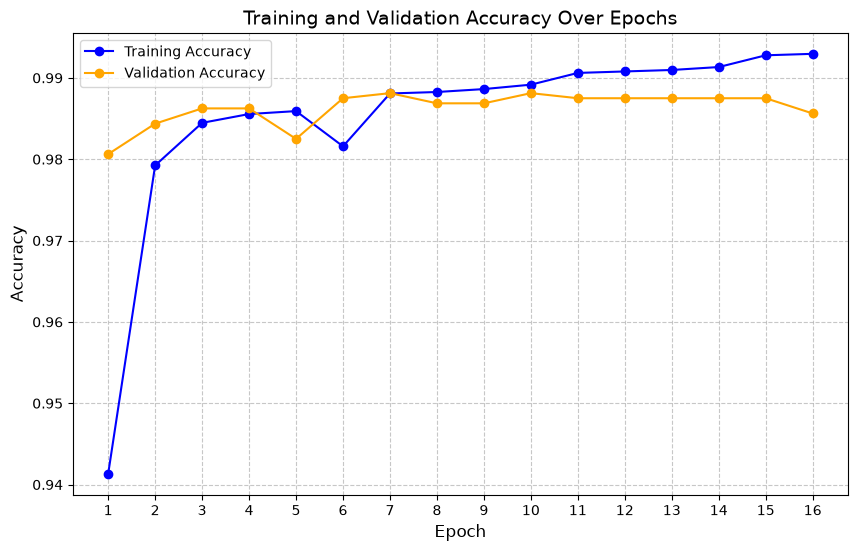

In [6]:
# Cell 6: Plot Training Progress
# Combine histories
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

# Plot accuracy
plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Training and Validation Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(len(acc)), range(1, len(acc) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 576ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 494ms/step
Test set class counts: {'CI': 192, 'CWI': 247, 'SOI': 334}
Test Accuracy: 0.9819
Test Precision: 0.9852
Test Recall: 0.9818
Test F1 Score: 0.9833


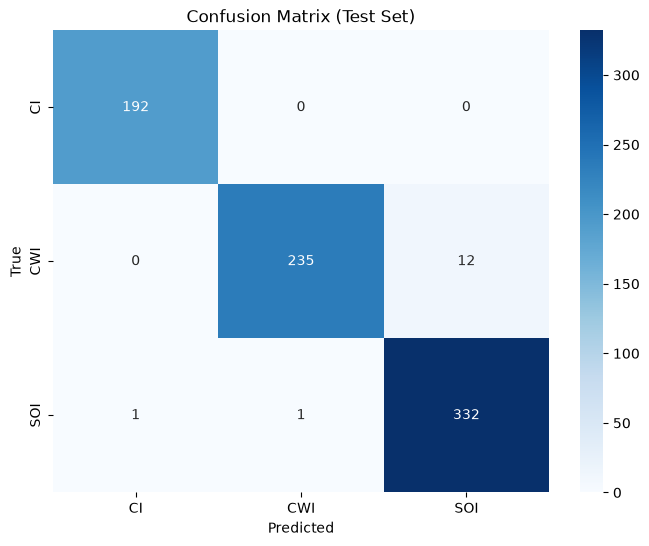

Average inference time per image: 16.631 ms

Classification Report (Test Set):
              precision    recall  f1-score   support

          CI       0.99      1.00      1.00       192
         CWI       1.00      0.95      0.97       247
         SOI       0.97      0.99      0.98       334

    accuracy                           0.98       773
   macro avg       0.99      0.98      0.98       773
weighted avg       0.98      0.98      0.98       773



In [7]:
# Cell 7: Evaluate on Test Set
# Predict on test set
model.predict(test_dataset)                  # warm-up: fill cache + trace the graph
start_time = time.time()
predictions = model.predict(test_dataset)    # timed on warm, cached data
end_time = time.time()

# Extract true labels
y_true = []
for _, label in test_dataset:
    y_true.extend(label.numpy())
y_true = np.array(y_true)
print("Test set class counts:", dict(zip(class_names, np.bincount(y_true, minlength=len(class_names)).tolist())))

# Get predicted labels
y_pred = np.argmax(predictions, axis=1)

# Compute metrics
metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'F1 Score': f1_score(y_true, y_pred, average='macro', zero_division=0)
}

for metric_name, value in metrics.items():
    print(f"Test {metric_name}: {value:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Inference time (measured on the warm run above)
num_test_images = len(y_true)
print(f"Average inference time per image: {(end_time - start_time) / num_test_images * 1000:.3f} ms")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_true, y_pred, labels=list(range(len(class_names))), target_names=class_names, zero_division=0))

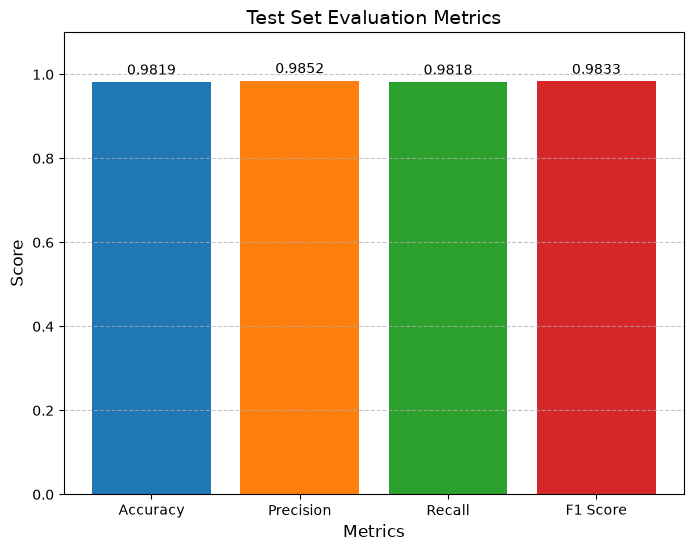

In [8]:
# Cell 8: Bar chart of the test-set metrics computed in the evaluation cell above.
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
bars = plt.bar(metrics.keys(), metrics.values(), color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
plt.ylim(0, 1.1)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Test Set Evaluation Metrics', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

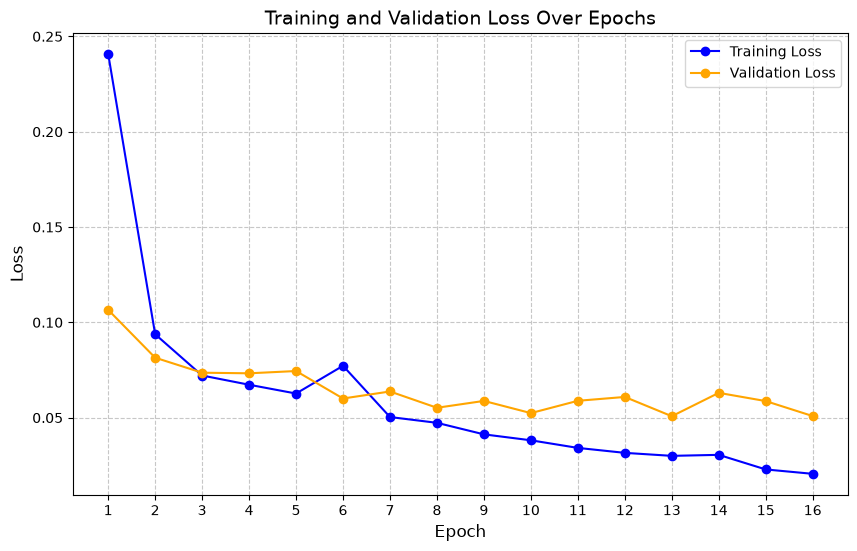

In [9]:
# Cell 9: Combined training/validation loss across both training phases.
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss', color='blue', marker='o')
plt.plot(val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(len(loss)), range(1, len(loss) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()